In [1]:
!pip install mlflow -q

In [2]:
import mlflow
import mlflow.sklearn

print("MLflow version:",mlflow.__version__)
print("MLflow imported successfully!")

MLflow version: 3.15.2
MLflow imported successfully!


In [3]:
print("best_lr:", "best_lr" in globals())
print("best_rf:", "best_rf" in globals())
print("best_xgb:", "best_xgb" in globals())
print("X_test:", "X_test" in globals())
print("y_test:", "y_test" in globals())

best_lr: False
best_rf: False
best_xgb: False
X_test: False
y_test: False


In [4]:
import pandas as pd
df=pd.read_csv('cleaned_churn_data.csv')
print("Data loaded successfully!")
print("Shape:",df.shape)

Data loaded successfully!
Shape: (4832, 23)


In [5]:
X=df.drop('Churn',axis=1)
y=df['Churn']
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (4832, 22)
y shape: (4832,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts().to_dict())

X_train: (3865, 22)
X_test: (967, 22)
y_train: (3865,)
y_test: (967,)

Training class distribution:
{0: 2596, 1: 1269}


In [7]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(
    X_train,
    y_train
)
print("Before SMOTE:",
      y_train.value_counts().to_dict())
print("After SMOTE:",
      y_train_smote.value_counts().to_dict())
print("X_train_smote:",X_train_smote.shape)
print("y_train_smote:",y_train_smote.shape)


Before SMOTE: {0: 2596, 1: 1269}
After SMOTE: {1: 2596, 0: 2596}
X_train_smote: (5192, 22)
y_train_smote: (5192,)


In [8]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

print("Random Forest recreated successfully!")
print(best_model)

Random Forest recreated successfully!
RandomForestClassifier(max_depth=10, random_state=42)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                        Feature  Importance
7                  TotalCharges    0.139114
3                        tenure    0.135000
6                MonthlyCharges    0.113319
11          OnlineSecurity_True    0.107864
14             TechSupport_True    0.096778
18            Contract_Two year    0.066184
17            Contract_One year    0.055999
12            OnlineBackup_True    0.037477
10  InternetService_Fiber optic    0.034713
1                       Partner    0.034613


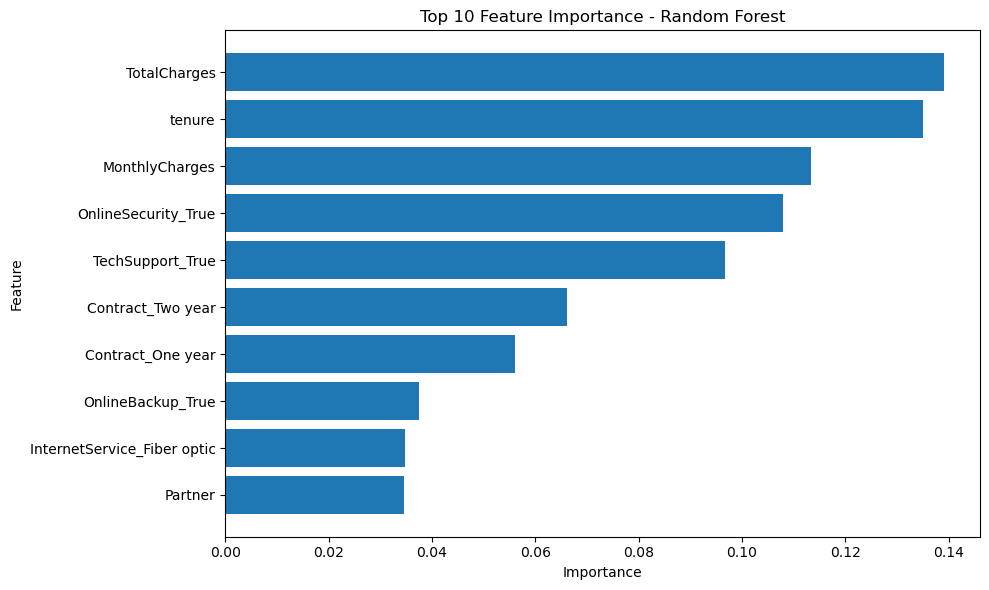

In [10]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [11]:
from lime.lime_tabular import LimeTabularExplainer

feature_names = X_train_smote.columns.tolist()

explainer = LimeTabularExplainer(
    X_train_smote.values,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    mode="classification",
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [12]:
import numpy as np

predictions = best_model.predict(X_test)

churn_idx = np.where(predictions == 1)[0][0]

print("Churn customer index:", churn_idx)
print("Predicted class:", predictions[churn_idx])
print("Churn probability:", best_model.predict_proba(X_test.iloc[[churn_idx]])[0][1])

Churn customer index: 1
Predicted class: 1
Churn probability: 0.7396001430925476


In [13]:
exp_churn = explainer.explain_instance(
    X_test.iloc[churn_idx].values,
    best_model.predict_proba,
    num_features=10
)

print("LIME explanation for churn customer:")
print(exp_churn.as_list())

C:\Users\nandha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for churn customer:
[('Contract_Two year <= 0.00', 0.1672595317396891), ('Contract_One year <= 0.00', 0.1486928427057958), ('OnlineSecurity_True <= 0.00', 0.1271072013812544), ('MonthlyCharges > 95.60', 0.11486829556852678), ('TechSupport_True <= 0.00', 0.10029273706464413), ('PaymentMethod_Mailed check <= 0.00', 0.06329005265429019), ('OnlineBackup_True <= 0.00', 0.06305539839362458), ('Dependents <= 0.00', 0.05292523419766745), ('PaymentMethod_Credit card (automatic) <= 0.00', 0.044592859605723546), ('24.00 < tenure <= 51.00', -0.038783078210064166)]


In [14]:
nonchurn_idx = np.where(predictions == 0)[0][0]

print("Non-churn customer index:", nonchurn_idx)
print("Predicted class:", predictions[nonchurn_idx])
print(
    "Churn probability:",
    best_model.predict_proba(X_test.iloc[[nonchurn_idx]])[0][1]
)

Non-churn customer index: 0
Predicted class: 0
Churn probability: 0.48577277659309287


In [15]:
exp_nonchurn = explainer.explain_instance(
    X_test.iloc[nonchurn_idx].values,
    best_model.predict_proba,
    num_features=10
)

print("LIME explanation for non-churn customer:")
print(exp_nonchurn.as_list())

C:\Users\nandha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME explanation for non-churn customer:
[('Contract_Two year <= 0.00', 0.17299067760328993), ('Contract_One year <= 0.00', 0.14793789225119583), ('OnlineSecurity_True <= 0.00', 0.13389768642879624), ('tenure <= 6.75', 0.10928267366078688), ('0.00 < TechSupport_True <= 1.00', -0.10910578643637708), ('Dependents <= 0.00', 0.05756853622655201), ('OnlineBackup_True <= 0.00', 0.05738496222222686), ('PaymentMethod_Mailed check <= 0.00', 0.05528107862452776), ('PaymentMethod_Credit card (automatic) <= 0.00', 0.05011850704710338), ('TotalCharges <= 477.55', 0.04385393914115209)]


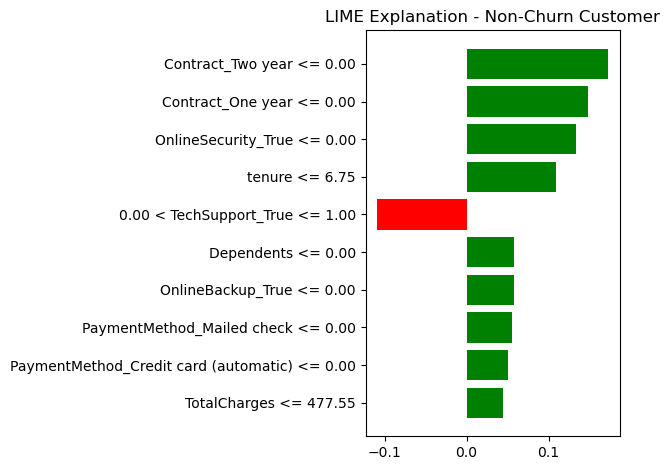

In [16]:
import matplotlib.pyplot as plt

fig = exp_nonchurn.as_pyplot_figure()
plt.title("LIME Explanation - Non-Churn Customer")
plt.tight_layout()
plt.show()

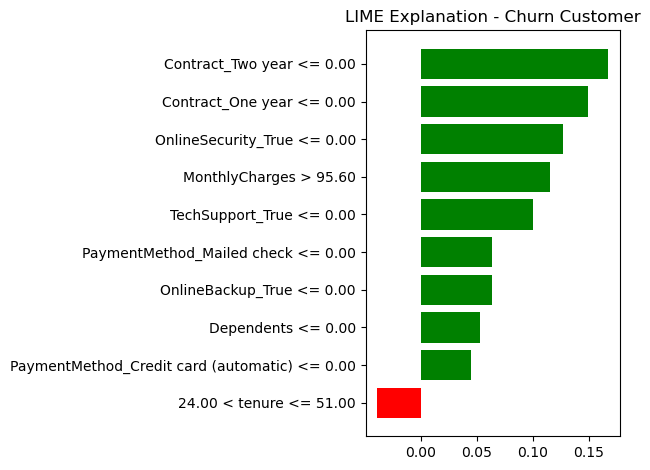

In [17]:
fig = exp_churn.as_pyplot_figure()
plt.title("LIME Explanation - Churn Customer")
plt.tight_layout()
plt.show()

In [18]:
print("Original dataset columns:")
print(df.columns.tolist())
print("\n Dtata types:")
print(df.dtypes)

Original dataset columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'MultipleLines_True', 'InternetService_Fiber optic', 'OnlineSecurity_True', 'OnlineBackup_True', 'DeviceProtection_True', 'TechSupport_True', 'StreamingTV_True', 'StreamingMovies_True', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

 Dtata types:
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                           

In [19]:
print("Model input columns:")
print(X.columns.tolist())
print("\nNumber of features:",len(X.columns))

Model input columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'MultipleLines_True', 'InternetService_Fiber optic', 'OnlineSecurity_True', 'OnlineBackup_True', 'DeviceProtection_True', 'TechSupport_True', 'StreamingTV_True', 'StreamingMovies_True', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Number of features: 22


In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

Before SMOTE: {0: 2596, 1: 1269}
After SMOTE: {1: 2596, 0: 2596}
X_train_smote: (5192, 22)
y_train_smote: (5192,)


In [21]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

print("Random Forest recreated successfully!")
print(best_model)

Random Forest recreated successfully!
RandomForestClassifier(max_depth=10, random_state=42)


In [22]:
def predict_new_customer(customer_data):
    try:
        
        if isinstance(customer_data, dict):
            customer_df = pd.DataFrame([customer_data])
        elif isinstance(customer_data, pd.DataFrame):
            customer_df = customer_data.copy()
        else:
            raise TypeError("Input must be a dictionary or a pandas DataFrame.")

        # Check exactly one customer
        if len(customer_df) != 1:
            raise ValueError("Input must contain exactly one customer.")

        # Required model features
        required_columns = X.columns.tolist()

        # Check for missing columns
        missing_columns = [
            col for col in required_columns
            if col not in customer_df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"Missing required fields: {missing_columns}"
            )

        # Keep only model input columns and correct order
        customer_df = customer_df[required_columns]

        # Check for missing values
        if customer_df.isnull().any().any():
            raise ValueError("Input contains missing values.")

        # Validate numeric values
        numeric_columns = X.select_dtypes(include="number").columns

        for col in numeric_columns:
            if not pd.api.types.is_numeric_dtype(customer_df[col]):
                raise TypeError(
                    f"Column '{col}' must contain numeric values."
                )

        # Validate tenure
        if "tenure" in customer_df.columns:
            tenure_value = customer_df["tenure"].iloc[0]

            if tenure_value < 0:
                raise ValueError("Tenure cannot be negative.")

        # Make prediction
        prediction = best_model.predict(customer_df)[0]
        probability = best_model.predict_proba(customer_df)[0][1]

        print("Prediction successful!")
        print("Predicted Churn:", prediction)
        print("Churn Probability:", round(probability, 4))

        return probability

    except (TypeError, ValueError) as e:
        print("Validation Error:", e)
        return None

In [23]:
print("X exists:", "X" in globals())
print("Number of columns:", len(X.columns))
print("Columns:")
print(X.columns.tolist())

X exists: True
Number of columns: 22
Columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'MultipleLines_True', 'InternetService_Fiber optic', 'OnlineSecurity_True', 'OnlineBackup_True', 'DeviceProtection_True', 'TechSupport_True', 'StreamingTV_True', 'StreamingMovies_True', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [24]:
# Test with a valid customer
valid_customer = X_test.iloc[[0]]

print("Testing valid customer...")
result = predict_new_customer(valid_customer)

print("Returned churn probability:", result)

Testing valid customer...
Prediction successful!
Predicted Churn: 0
Churn Probability: 0.4858
Returned churn probability: 0.48577277659309287


In [25]:
# Bad Input Test 1: Missing required fields

bad_customer_1 = valid_customer.drop(
    columns=["tenure", "MonthlyCharges"]
)

print("Testing customer with missing fields...")

result = predict_new_customer(bad_customer_1)

print("Returned result:", result)

Testing customer with missing fields...
Validation Error: Missing required fields: ['tenure', 'MonthlyCharges']
Returned result: None


In [26]:
# Bad Input Test 2: Negative tenure

bad_customer_2 = valid_customer.copy()
bad_customer_2["tenure"] = -5

print("Testing customer with negative tenure...")

result = predict_new_customer(bad_customer_2)

print("Returned result:", result)

Testing customer with negative tenure...
Validation Error: Tenure cannot be negative.
Returned result: None


In [27]:
print("===== TASK 16 COMPLETION CHECK =====")
print("1. Valid customer prediction: PASSED")
print("2. Missing required fields validation: PASSED")
print("3. Negative tenure validation: PASSED")
print("4. Clear error messages: PASSED")
print("5. Safe handling without crashes: PASSED")
print("====================================")

===== TASK 16 COMPLETION CHECK =====
1. Valid customer prediction: PASSED
2. Missing required fields validation: PASSED
3. Negative tenure validation: PASSED
4. Clear error messages: PASSED
5. Safe handling without crashes: PASSED


In [28]:
print("Checking Task 17 prerequisites...")
print("Model available:", "best_model" in globals())
print("X available:", "X" in globals())
print("Number of features:", len(X.columns))

print("\nModel:")
print(best_model)

Checking Task 17 prerequisites...
Model available: True
X available: True
Number of features: 22

Model:
RandomForestClassifier(max_depth=10, random_state=42)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib

# Raw customer columns
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Complete reusable pipeline
churn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", best_model)
])

print("Reusable pipeline created successfully!")
print(churn_pipeline)

Reusable pipeline created successfully!
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'PaperlessBilling',
                                                   'MultipleLines',
                                    

In [30]:
# Check that pipeline preprocessing matches the trained model features

preprocessor.fit(df.drop(columns=["Churn"]))

transformed_features = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(transformed_features))
print("Expected model features:", X.shape[1])

print("\nTransformed feature names:")
print(transformed_features)

ValueError: Some column names are not columns of the dataframe: {'TechSupport', 'Contract', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'DeviceProtection', 'StreamingMovies', 'StreamingTV', 'gender', 'OnlineBackup', 'PaymentMethod'}

In [31]:
print(df.columns.tolist())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'MultipleLines_True', 'InternetService_Fiber optic', 'OnlineSecurity_True', 'OnlineBackup_True', 'DeviceProtection_True', 'TechSupport_True', 'StreamingTV_True', 'StreamingMovies_True', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [32]:
from sklearn.pipeline import Pipeline
import joblib

# Your dataset is already preprocessed into the 22 model features.
# Therefore, preprocessing is kept as passthrough.
churn_pipeline = Pipeline([
    ("preprocessing", "passthrough"),
    ("model", best_model)
])

print("Correct reusable pipeline created!")
print("\nPipeline:")
print(churn_pipeline)

Correct reusable pipeline created!

Pipeline:
Pipeline(steps=[('preprocessing', 'passthrough'),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])


In [33]:
# Save the complete reusable pipeline

pipeline_file = "churn_model_pipeline.pkl"

joblib.dump(churn_pipeline, pipeline_file)

print("Pipeline saved successfully!")
print("File:", pipeline_file)

Pipeline saved successfully!
File: churn_model_pipeline.pkl


In [34]:
# Load the saved pipeline

loaded_pipeline = joblib.load("churn_model_pipeline.pkl")

print("Pipeline loaded successfully!")
print(loaded_pipeline)

Pipeline loaded successfully!
Pipeline(steps=[('preprocessing', 'passthrough'),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])


In [35]:
# Load the saved pipeline

loaded_pipeline = joblib.load("churn_model_pipeline.pkl")

print("Pipeline loaded successfully!")
print(loaded_pipeline)

Pipeline loaded successfully!
Pipeline(steps=[('preprocessing', 'passthrough'),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])


In [36]:
# Create a new sample customer

new_customer = X.iloc[[0]].copy()

# Change a few values to make this a new sample
new_customer["tenure"] = 5
new_customer["MonthlyCharges"] = 105.0
new_customer["TotalCharges"] = 525.0

# Predict using the SAVED and LOADED pipeline
prediction = loaded_pipeline.predict(new_customer)[0]
churn_probability = loaded_pipeline.predict_proba(new_customer)[0][1]

print("Prediction using loaded pipeline:")
print("Predicted class:", prediction)
print("Churn probability:", round(churn_probability, 4))

Prediction using loaded pipeline:
Predicted class: 0
Churn probability: 0.334


In [37]:
%%writefile predict_churn.py

import joblib
import pandas as pd

# Load saved pipeline
pipeline = joblib.load("churn_model_pipeline.pkl")

# Brand-new customer sample
new_customer = pd.DataFrame([{
    "SeniorCitizen": 0,
    "Partner": 0,
    "Dependents": 0,
    "tenure": 5,
    "PhoneService": 1,
    "PaperlessBilling": 1,
    "MonthlyCharges": 105.0,
    "TotalCharges": 525.0,
    "gender_Male": 1,
    "MultipleLines_True": 0,
    "InternetService_Fiber optic": 1,
    "OnlineSecurity_True": 0,
    "OnlineBackup_True": 0,
    "DeviceProtection_True": 0,
    "TechSupport_True": 0,
    "StreamingTV_True": 1,
    "StreamingMovies_True": 1,
    "Contract_One year": 0,
    "Contract_Two year": 0,
    "PaymentMethod_Credit card (automatic)": 0,
    "PaymentMethod_Electronic check": 1,
    "PaymentMethod_Mailed check": 0
}])

prediction = pipeline.predict(new_customer)[0]
probability = pipeline.predict_proba(new_customer)[0][1]

print("Independent prediction using saved pipeline")
print("Predicted class:", prediction)
print("Churn probability:", round(probability, 4))

Writing predict_churn.py


In [38]:
!python predict_churn.py

Independent prediction using saved pipeline
Predicted class: 1
Churn probability: 0.8707


In [39]:
# Final Task 17 verification

direct_prediction = best_model.predict(new_customer)[0]
direct_probability = best_model.predict_proba(new_customer)[0][1]

saved_prediction = loaded_pipeline.predict(new_customer)[0]
saved_probability = loaded_pipeline.predict_proba(new_customer)[0][1]

print("FINAL PIPELINE VERIFICATION")
print("----------------------------")
print("Original model prediction:", direct_prediction)
print("Loaded pipeline prediction:", saved_prediction)

print("Original model probability:", round(direct_probability, 4))
print("Loaded pipeline probability:", round(saved_probability, 4))

print("\nPrediction matches:", direct_prediction == saved_prediction)
print("Probability matches:", abs(direct_probability - saved_probability) < 0.000001)

FINAL PIPELINE VERIFICATION
----------------------------
Original model prediction: 0
Loaded pipeline prediction: 0
Original model probability: 0.334
Loaded pipeline probability: 0.334

Prediction matches: True
Probability matches: True
